In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [5]:
encoder = LabelEncoder()

In [8]:
df['species'] = encoder.fit_transform(df['species'])

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [13]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


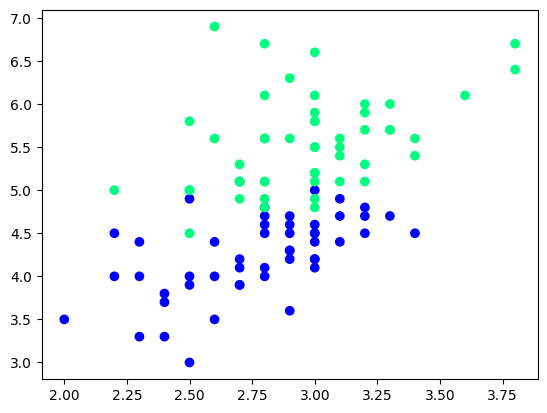

In [14]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,sepal_width,petal_length,species
114,2.8,5.1,2
137,3.1,5.5,2
104,3.0,5.8,2
90,2.6,4.4,1
118,2.6,6.9,2
71,2.8,4.0,1
59,2.7,3.9,1
134,2.6,5.6,2
110,3.2,5.1,2
89,2.5,4.0,1


In [19]:
df_val

,sepal_width,petal_length,species
62,2.2,4.0,1
63,2.9,4.7,1
136,3.4,5.6,2
139,3.1,5.4,2
113,2.5,5.0,2


In [20]:
df_test

,sepal_width,petal_length,species
99,2.8,4.1,1
61,3.0,4.2,1
97,2.9,4.3,1
126,2.8,4.8,2
81,2.4,3.7,1


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([1, 1, 2, 2, 2])

# Case 1 - Bagging

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X_train = df_bag.iloc[:,0:2]
y_train = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
110,3.2,5.1,2
89,2.5,4.0,1
104,3.0,5.8,2
59,2.7,3.9,1
118,2.6,6.9,2
90,2.6,4.4,1
71,2.8,4.0,1
59,2.7,3.9,1


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [26]:
dt_bag1 = DecisionTreeClassifier()

In [27]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

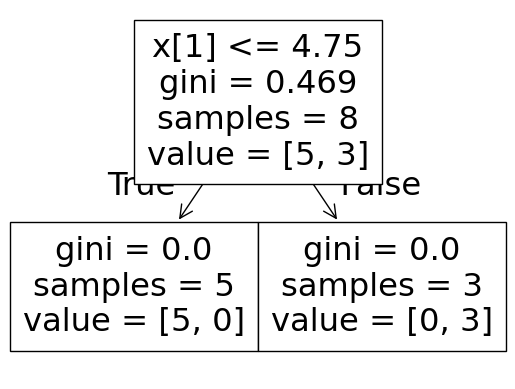

c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


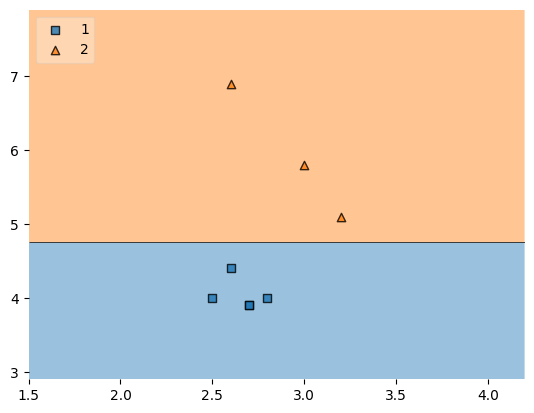

In [29]:
evaluate(dt_bag1,X_train,y_train)

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X_train = df_bag.iloc[:,0:2]
y_train = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
137,3.1,5.5,2
71,2.8,4.0,1
134,2.6,5.6,2
118,2.6,6.9,2
90,2.6,4.4,1
71,2.8,4.0,1
90,2.6,4.4,1
110,3.2,5.1,2


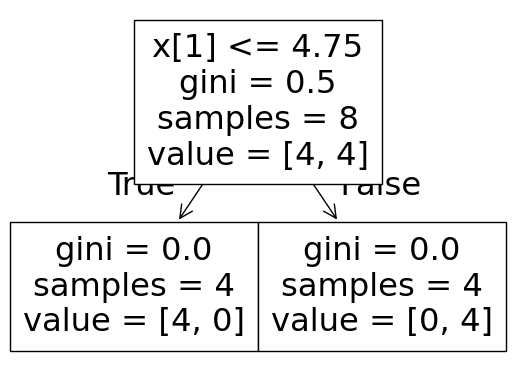

1.0


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


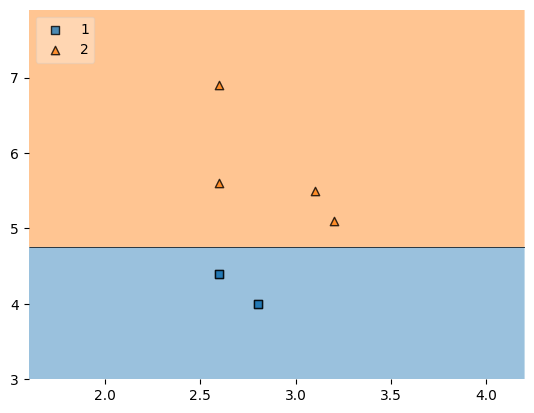

In [32]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X_train,y_train)

In [33]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal_width,petal_length,species
134,2.6,5.6,2
114,2.8,5.1,2
71,2.8,4.0,1
110,3.2,5.1,2
137,3.1,5.5,2
90,2.6,4.4,1
89,2.5,4.0,1
89,2.5,4.0,1


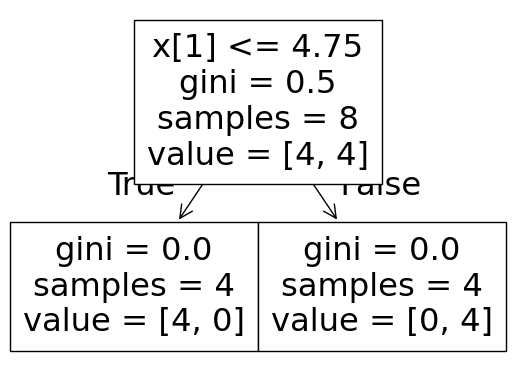

1.0


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


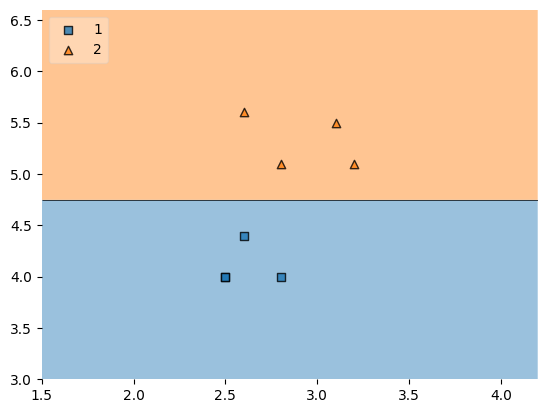

In [34]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [35]:
df_test

,sepal_width,petal_length,species
99,2.8,4.1,1
61,3.0,4.2,1
97,2.9,4.3,1
126,2.8,4.8,2
81,2.4,3.7,1


In [36]:
print("Predictor 1",dt_bag1.predict(np.array([2.8,4.8]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,4.8]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,4.8]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [37]:
# Row sampling without replacement
df_train

,sepal_width,petal_length,species
114,2.8,5.1,2
137,3.1,5.5,2
104,3.0,5.8,2
90,2.6,4.4,1
118,2.6,6.9,2
71,2.8,4.0,1
59,2.7,3.9,1
134,2.6,5.6,2
110,3.2,5.1,2
89,2.5,4.0,1


In [38]:
df_train.sample(8)

,sepal_width,petal_length,species
90,2.6,4.4,1
118,2.6,6.9,2
71,2.8,4.0,1
134,2.6,5.6,2
114,2.8,5.1,2
104,3.0,5.8,2
110,3.2,5.1,2
137,3.1,5.5,2


# Random Subspaces

In [40]:
df1 = sns.load_dataset('iris')
df1 = df1.sample(10)

In [41]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
126,6.2,2.8,4.8,1.8,virginica
78,6.0,2.9,4.5,1.5,versicolor
30,4.8,3.1,1.6,0.2,setosa
99,5.7,2.8,4.1,1.3,versicolor
1,4.9,3.0,1.4,0.2,setosa
120,6.9,3.2,5.7,2.3,virginica
129,7.2,3.0,5.8,1.6,virginica
17,5.1,3.5,1.4,0.3,setosa
23,5.1,3.3,1.7,0.5,setosa
97,6.2,2.9,4.3,1.3,versicolor


In [50]:
df1.sample(2,replace=True,axis=1)

,species,petal_width
126,virginica,1.8
78,versicolor,1.5
30,setosa,0.2
99,versicolor,1.3
1,setosa,0.2
120,virginica,2.3
129,virginica,1.6
17,setosa,0.3
23,setosa,0.5
97,versicolor,1.3


# Random Patches

In [51]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
126,6.2,2.8,4.8,1.8,virginica
78,6.0,2.9,4.5,1.5,versicolor
30,4.8,3.1,1.6,0.2,setosa
99,5.7,2.8,4.1,1.3,versicolor
1,4.9,3.0,1.4,0.2,setosa
120,6.9,3.2,5.7,2.3,virginica
129,7.2,3.0,5.8,1.6,virginica
17,5.1,3.5,1.4,0.3,setosa
23,5.1,3.3,1.7,0.5,setosa
97,6.2,2.9,4.3,1.3,versicolor


In [52]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,petal_length,petal_length
17,1.4,1.4
129,5.8,5.8
23,1.7,1.7
99,4.1,4.1
99,4.1,4.1
30,1.6,1.6
17,1.4,1.4
126,4.8,4.8
